Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

Load Festival Dataset

In [3]:
df = pd.read_csv(
    "../data/processed/festival_enriched_sales.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)

df.head()

(6435, 24)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,...,WeekendFlag,Festival_Flag,Festival_Name,Festival_Score,Days_To_Festival,Festival_Week,Festival_Month,Festival_Impact_Score,Pre_Festival_Flag,Post_Festival_Flag
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,...,0,0,NaN,0,9,0,0,21,0,0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,...,0,1,Valentines_Day,6,2,6,2,34,1,0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,...,0,1,Valentines_Day,6,5,6,2,31,0,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,...,0,1,Holi,8,3,9,3,35,1,0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,...,0,1,Holi,8,4,9,3,34,0,1


Create Base Trend Score

In [4]:
sales_scaled = (
    (df["Weekly_Sales"] - df["Weekly_Sales"].min())
    /
    (df["Weekly_Sales"].max() - df["Weekly_Sales"].min())
)

df["Trend_Score"] = (
    sales_scaled * 40
    +
    df["Festival_Score"] * 5
    +
    np.random.normal(10, 5, len(df))
)

Normalize Trend Score (0–100)

In [5]:
df["Trend_Score"] = (
    100 *
    (
        df["Trend_Score"]
        -
        df["Trend_Score"].min()
    )
    /
    (
        df["Trend_Score"].max()
        -
        df["Trend_Score"].min()
    )
)

df["Trend_Score"] = df["Trend_Score"].round(2)

In [6]:
df["Trend_Score"].describe()

count    6435.000000
mean       38.378561
std        20.418925
min         0.000000
25%        20.110000
50%        33.250000
75%        56.300000
max       100.000000
Name: Trend_Score, dtype: float64

Generate Mention Count

In [7]:
df["Mention_Count"] = (

    df["Trend_Score"] * 100

    +

    np.random.randint(
        500,
        5000,
        len(df)
    )

).astype(int)

### Generate Engagement Rate

Range: 1% to 20%

In [8]:
df["Engagement_Rate"] = (

    0.01

    +

    (
        df["Trend_Score"] / 100
    ) * 0.19

    +

    np.random.normal(
        0,
        0.01,
        len(df)
    )

)

df["Engagement_Rate"] = np.clip(
    df["Engagement_Rate"],
    0.01,
    0.20
)

df["Engagement_Rate"] = (
    df["Engagement_Rate"] * 100
).round(2)

### Generate Sentiment Score

Range: -1 to +1

In [9]:
df["Sentiment_Score"] = (

    np.random.normal(
        0.2,
        0.3,
        len(df)
    )

    +

    (
        df["Festival_Score"] / 20
    )

)

df["Sentiment_Score"] = np.clip(
    df["Sentiment_Score"],
    -1,
    1
)

df["Sentiment_Score"] = (
    df["Sentiment_Score"]
).round(3)

### Influencer Promotion Flag

Higher trend = higher probability.

In [10]:
probability = (
    df["Trend_Score"] / 100
)

df["Influencer_Promotion_Flag"] = np.where(

    np.random.rand(len(df))
    <
    probability,

    1,

    0
)

Viral Campaign Feature

In [11]:
df["Viral_Campaign_Flag"] = np.where(

    (
        df["Trend_Score"] > 80
    )

    &

    (
        df["Influencer_Promotion_Flag"] == 1
    ),

    1,

    0
)

Verify Features

In [12]:
social_cols = [

    "Trend_Score",

    "Mention_Count",

    "Engagement_Rate",

    "Sentiment_Score",

    "Influencer_Promotion_Flag",

    "Viral_Campaign_Flag"

]

df[social_cols].head()

,Trend_Score,Mention_Count,Engagement_Rate,Sentiment_Score,Influencer_Promotion_Flag,Viral_Campaign_Flag
0,30.12,5908,6.40,0.105,0,0
1,56.02,6544,11.93,0.225,0,0
2,59.49,10060,11.47,0.994,1,0
3,71.22,11999,15.74,0.818,1,0
4,64.28,9335,14.37,0.632,1,0


Trend Score vs Sales

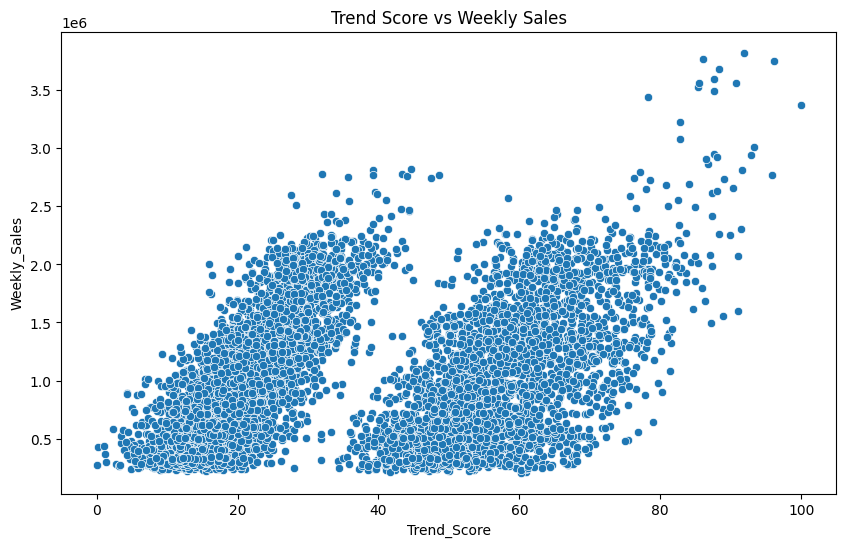

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Trend_Score",
    y="Weekly_Sales"
)

plt.title(
    "Trend Score vs Weekly Sales"
)

plt.show()

Sentiment vs Sales

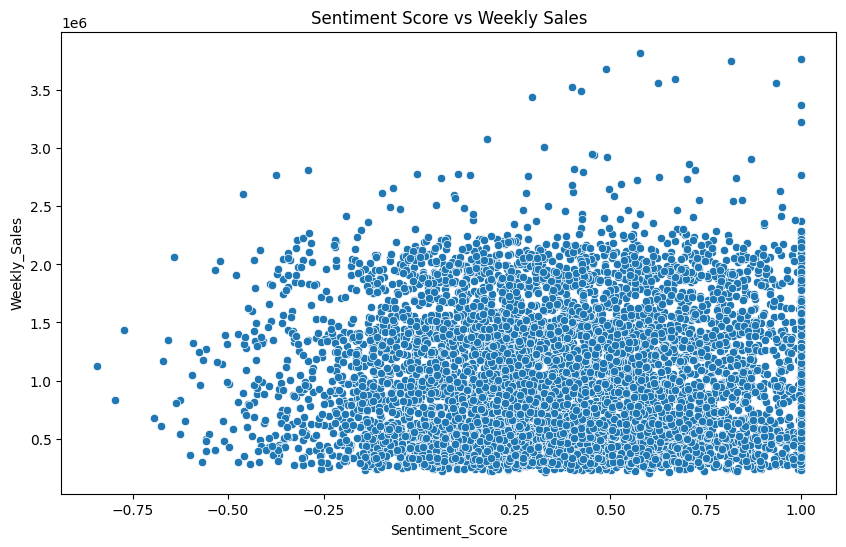

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Sentiment_Score",
    y="Weekly_Sales"
)

plt.title(
    "Sentiment Score vs Weekly Sales"
)

plt.show()

Mentions vs Sales

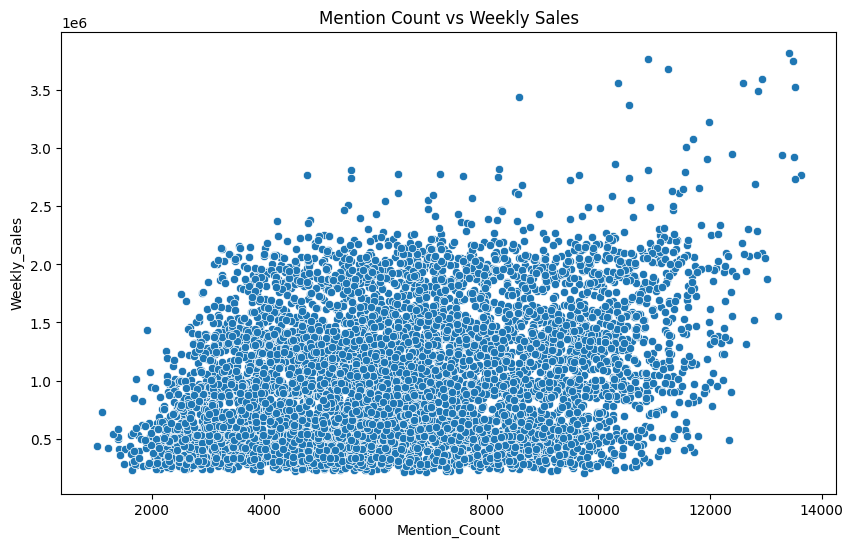

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Mention_Count",
    y="Weekly_Sales"
)

plt.title(
    "Mention Count vs Weekly Sales"
)

plt.show()

Correlation Analysis

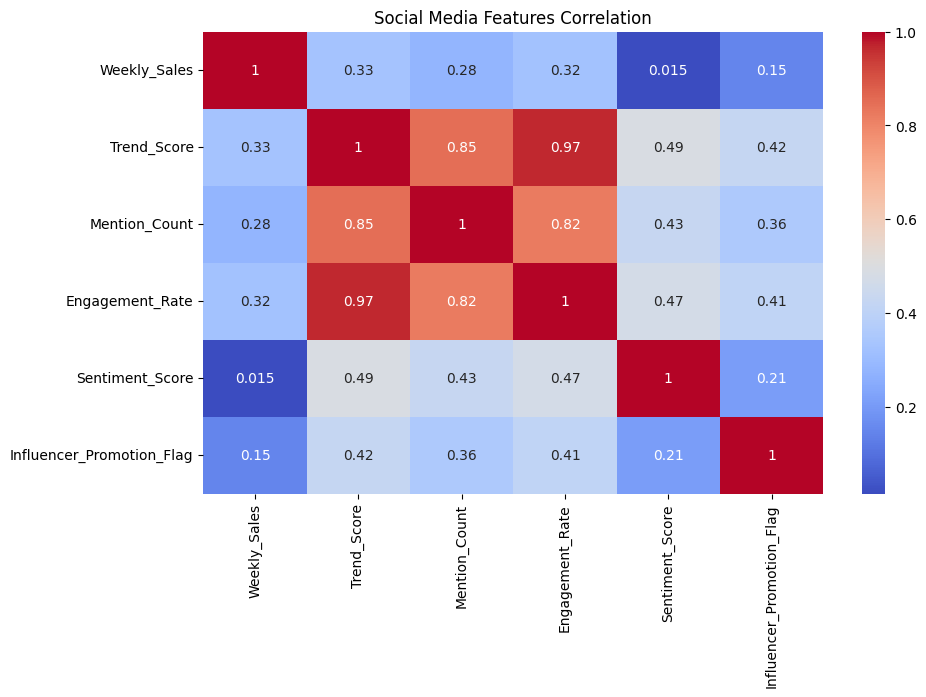

In [16]:
social_features = [

    "Weekly_Sales",

    "Trend_Score",

    "Mention_Count",

    "Engagement_Rate",

    "Sentiment_Score",

    "Influencer_Promotion_Flag"

]

plt.figure(figsize=(10,6))

sns.heatmap(

    df[social_features]
    .corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title(
    "Social Media Features Correlation"
)

plt.show()

Save Dataset

In [17]:
df.to_csv(
    "../data/processed/social_media_enriched_sales.csv",
    index=False
)

print(
    "Social media enriched dataset saved successfully!"
)

Social media enriched dataset saved successfully!
